In [91]:
import pandas as pd
df = pd.read_csv('corri.csv', sep=';')
df.head(3)


,podcast_id,guest_id,date,amount,name,creation_date,title,category,sponsor_id,extra_info,subject
0,150,983,12/01/2020,246,"Anderson, Mcguire and Burke",02/01/2020,Beat,research,Sem Patrocinador,NaN,Health
1,221,125,12/01/2020,1284,Brown and Sons,02/01/2020,Recently,drop,Sem Patrocinador,NaN,Technology
2,303,485,12/01/2020,4500,Sanchez Ltd,02/01/2020,Mind,seat,89.0,live,Science


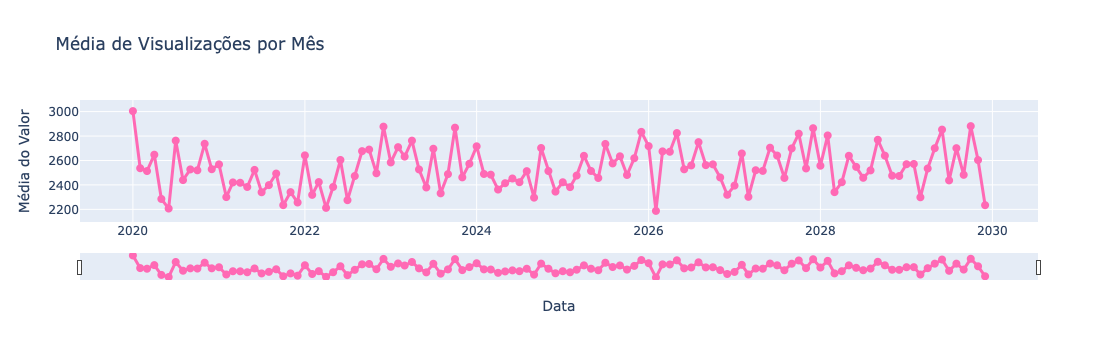

In [ ]:

import pandas as pd
import plotly.express as px

df = pd.read_csv('corri.csv', sep=';')


df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['month_year'] = df['date'].dt.to_period('M').astype(str) 


df_temporal = df.groupby('month_year')['amount'].agg(['mean', 'max', 'sum']).reset_index()

fig = px.line(
    df_temporal, 
    x='month_year', 
    y='mean', 
    title='Média de Visualizações por Mês',
    labels={'mean': 'Média do Valor', 'month_year': 'Data'},
    markers=True
)


fig.update_traces(line=dict(color='hotpink', width=3), marker=dict(size=8))


fig.update_xaxes(rangeslider_visible=True)

fig.show()

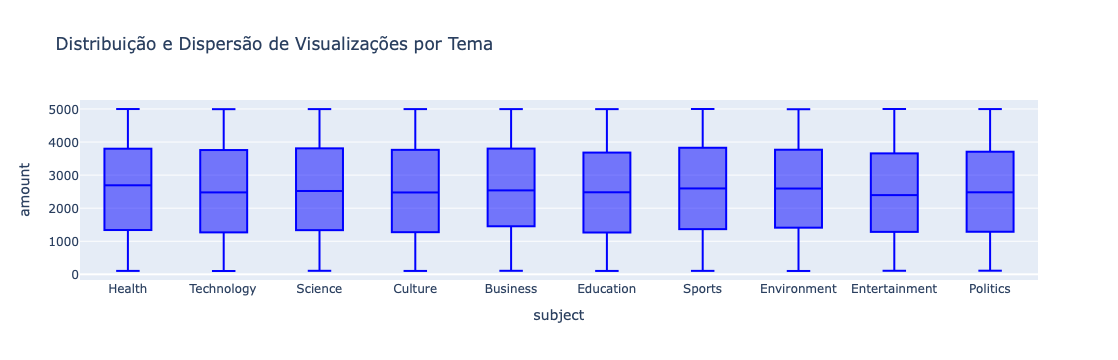

In [125]:

fig3 = px.box(df, x='subject', y='amount', color_discrete_sequence=['blue'] ,
              title='Distribuição e Dispersão de Visualizações por Tema')
fig3.show()

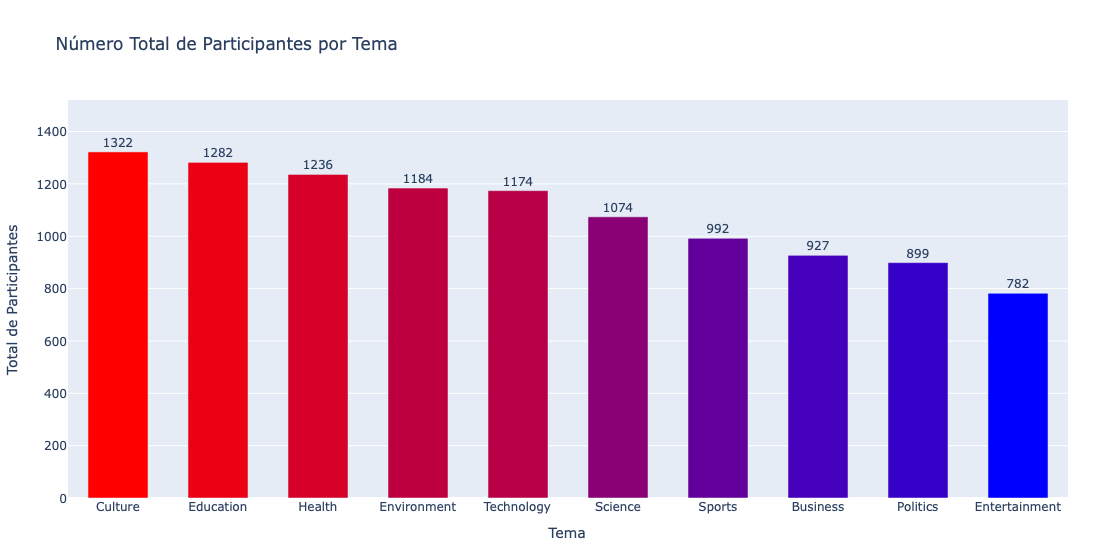

In [ ]:


import pandas as pd
import plotly.express as px

df = pd.read_csv('versao_final.csv', sep=';', skiprows=1)

df_participantes = df.groupby('subject').size().reset_index(name='total_participantes')

df_participantes = df_participantes.sort_values(by='total_participantes', ascending=False)


fig = px.bar(
    df_participantes, 
    x='subject',          
    y='total_participantes',           
    title='Número Total de Participantes por Tema',
    color='total_participantes',         
    color_continuous_scale='Bluered',    
    text_auto=True                       
)

fig.update_traces(
    width=0.6,
    textposition='outside'              
)

fig.update_layout(
    margin=dict(t=100, b=50, l=50, r=50), 
    width=950,  
    height=550,
    xaxis_title="Tema",
    yaxis_title="Total de Participantes",
    yaxis=dict(range=[0, df_participantes['total_participantes'].max() * 1.15]), # Evita cortes
    coloraxis_showscale=False            
)

fig.show()

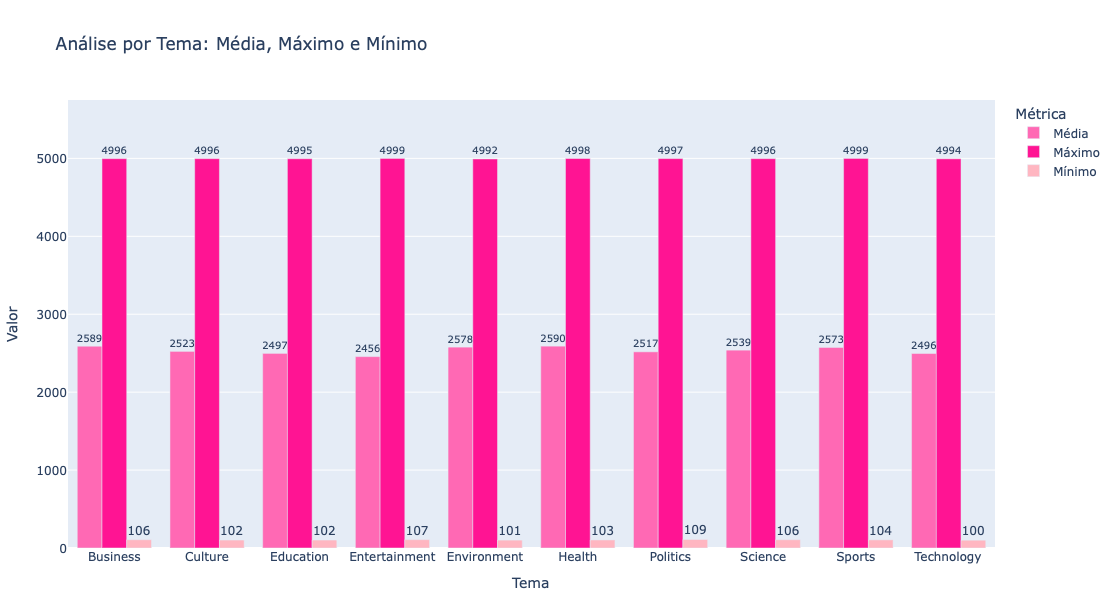

In [ ]:


import pandas as pd
import plotly.express as px

df = pd.read_csv('versao_final.csv', sep=';', skiprows=1)


df_metricas = df.groupby('subject')['amount'].agg(['mean', 'max', 'min']).reset_index()
df_metricas.columns = ['Tema', 'Média', 'Máximo', 'Mínimo']

df_melt = df_metricas.melt(id_vars='Tema', value_vars=['Média', 'Máximo', 'Mínimo'], 
                           var_name='Métrica', value_name='Valor')


fig2 = px.bar(
    df_melt, 
    x='Tema', 
    y='Valor', 
    color='Métrica',
    barmode='group',
    text_auto='.0f', 
    title='Análise por Tema: Média, Máximo e Mínimo',
    color_discrete_sequence=['hotpink', 'deeppink', 'lightpink']
)


fig2.update_traces(textposition='outside')

fig2.update_layout(
    margin=dict(t=100, b=50, l=50, r=50),
    width=1000,
    height=600,
    yaxis=dict(range=[0, df_melt['Valor'].max() * 1.15])
)

fig2.show()